# Notebook 2 — Ball Tracking (TrackNet)

**TFM: Análisis de tenis mediante Computer Vision**

Objetivo: entrenar una red **TrackNet** (encoder VGG-like + decoder con upsampling y skip connections) sobre el dataset TrackNet de tenis, y exportar las posiciones predichas de la pelota a `outputs/tracking/ball_positions.csv`.

**Entrada al modelo:** 3 frames consecutivos apilados como tensor (9 canales).  
**Salida:** heatmap 2D centrado en la pelota (gaussiano, σ=5px).  
**Resolución de trabajo:** 640×360.  
**Split:** 80/20 por clip (sin mezclar frames de un mismo clip entre train y val).

Requisitos para ejecutar: `Kernel → Restart & Run All`.

## Índice

1. Configuración
2. Exploración del dataset
3. Dataset PyTorch
4. Arquitectura TrackNet
5. Funciones de entrenamiento e inferencia
6. Grid search y selección del modelo final
7. Inferencia sobre el clip de prueba
8. Exportar CSV

In [16]:
# ── Stdlib ──
import random
import re
import time
import warnings
from pathlib import Path
import shutil

# ── Numérico / datos ──
import numpy as np
import pandas as pd

# ── Visión artificial ──
import cv2

# ── Deep learning ──
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models

# ── Visualización ──
import matplotlib.pyplot as plt

# ── IPython ──
from IPython.display import HTML
from base64 import b64encode

# ── Scipy ──
from scipy.ndimage import maximum_filter

## 1. Configuración

In [17]:
# ----- Rutas -----
# El proyecto se ancla al directorio de trabajo actual. Ejecuta el notebook desde
# la raíz del proyecto (/workspace/TFM) para que DATASET_ROOT y OUTPUTS_ROOT
# apunten al sitio correcto.
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "Dataset"
TEST_ROOT = PROJECT_ROOT / "test"      # clips fuera del dataset de entrenamiento (no se usan en build_samples)
OUTPUTS_ROOT = PROJECT_ROOT / "outputs"
MODELS_OUT = OUTPUTS_ROOT / "grid_models"
TRACKING_OUT = OUTPUTS_ROOT / "tracking"
MODELS_OUT.mkdir(parents=True, exist_ok=True)
TRACKING_OUT.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODELS_OUT / "tracknet_best.pth"
OUTPUT_CSV = TRACKING_OUT / "ball_positions.csv"

# ----- Dataset / preprocesado -----
INPUT_W = 640
INPUT_H = 360
N_INPUT_FRAMES = 3              # apilar 3 frames consecutivos -> 9 canales
GAUSSIAN_SIGMA = 5.0             # σ del heatmap objetivo (en píxeles de INPUT_W x INPUT_H)
VAL_SPLIT = 0.20
RANDOM_SEED = 42

# ----- Entrenamiento -----
# A100 80GB + 128 vCPU: BATCH_SIZE y NUM_WORKERS subidos frente a la pod L4
# original (8/4) para no dejar la GPU ociosa esperando al dataloader (CPU-bound
# por la decodificación/resize de 3 frames JPEG por muestra).
BATCH_SIZE = 32
NUM_WORKERS = 32

# Fase 1: solo decoder + primera conv del encoder (warmup, protege el encoder
# preentrenado de ImageNet de gradientes grandes del decoder sin entrenar).
# Fijos en todas las combinaciones del grid search (sección 6).
# Reducido de 10 a 6 épocas para acotar el coste total del grid (~4h en la L4
# de RunPod); riesgo aceptado: el decoder puede converger algo menos antes de
# pasar a fase 2, a cambio de recortar tiempo en las 6 combinaciones por igual.
PHASE1_EPOCHS = 6
PHASE1_LR = 1e-3
EARLY_STOPPING_PATIENCE = 3
POS_WEIGHT = 100.0               # peso de los píxeles positivos en weighted_mse

# Fase 2 (fine-tuning del encoder): NO se fija aquí. phase2_lr y phase2_epochs
# son justo lo que decide el grid search de la sección 6 (PHASE2_LR_GRID,
# PHASE2_EPOCHS_GRID) — no existen como valores únicos hasta que el grid
# search elige el ganador.

# ----- Inferencia / test final -----
# Clip de TEST_ROOT (fuera del dataset de entrenamiento, nunca visto por el
# modelo) usado como prueba final en la sección 7.
INFER_GAME = "game0"
INFER_CLIP = "Clip1"
# umbral para considerar pelota detectada
HEATMAP_THRESHOLD = 0.4
# distancia máxima (px, resolución de trabajo) entre frames consecutivos para
# aceptar un candidato; evita saltos lejanos por activaciones espúreas
MAX_JUMP_PX = 80.0

# ----- Device -----
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    warnings.warn(
        "No se ha detectado GPU. El entrenamiento será MUY lento en CPU; "
        "considera reducir PHASE2_EPOCHS_GRID o entrenar en una máquina con GPU.",
        stacklevel=2,
    )
    print("Ejecutando en CPU.")

torch.manual_seed(RANDOM_SEED)
print(f"Dataset: {DATASET_ROOT}")
print(f"Modelo se guardará en: {BEST_MODEL_PATH}")

GPU detectada: NVIDIA A100 80GB PCIe
Dataset: /workspace/TFM/Dataset
Modelo se guardará en: /workspace/TFM/outputs/grid_models/tracknet_best.pth


In [18]:
# En RunPod/local el dataset ya está en disco (DATASET_ROOT = ./Dataset), no hay
# que montar Google Drive ni copiar nada. Solo verificamos que esté disponible.
if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"No se encuentra el dataset en {DATASET_ROOT}. "
        "Asegúrate de ejecutar el notebook desde la raíz del proyecto "
        "(/workspace/TFM) o ajusta PROJECT_ROOT en la celda de configuración."
    )
n_clips = sum(1 for g in DATASET_ROOT.iterdir() if g.is_dir() and g.name.lower().startswith("game")
              for c in g.iterdir() if c.is_dir() and (c / "Label.csv").exists())
print(f"Dataset OK en {DATASET_ROOT} — {n_clips} clips con Label.csv")

Dataset OK en /workspace/TFM/Dataset — 95 clips con Label.csv


## 2. Exploración del dataset

In [19]:
def find_clip_dirs(dataset_root: Path):
    """Devuelve la lista de directorios de clips que contienen un Label.csv."""
    clips = []
    for game_dir in sorted(dataset_root.iterdir()):
        if not game_dir.is_dir() or not game_dir.name.lower().startswith("game"):
            continue
        for clip_dir in sorted(game_dir.iterdir()):
            if clip_dir.is_dir() and (clip_dir / "Label.csv").exists():
                clips.append(clip_dir)
    return clips

clip_dirs = find_clip_dirs(DATASET_ROOT)
print(f"Clips encontrados: {len(clip_dirs)}")

# Cargar todos los Label.csv y concatenarlos para exploración global
all_labels = []
for c in clip_dirs:
    df = pd.read_csv(c / "Label.csv")
    df["clip"] = f"{c.parent.name}/{c.name}"
    all_labels.append(df)
labels = pd.concat(all_labels, ignore_index=True)
labels.columns = [col.strip() for col in labels.columns]
print(f"Imágenes totales: {len(labels)}")
print(f"Visibility=1:    {(labels['visibility'] == 1).sum()}")
print(f"Visibility=0:    {(labels['visibility'] == 0).sum()}")
print(f"Rebotes (status=1): {(labels['status'] == 1).sum()}")
labels.head()

Clips encontrados: 95
Imágenes totales: 19835
Visibility=1:    17632
Visibility=0:    729
Rebotes (status=1): 516


,file name,visibility,x-coordinate,y-coordinate,status,clip
0,0000.jpg,1,599.0,423.0,0.0,game1/Clip1
1,0001.jpg,1,601.0,406.0,0.0,game1/Clip1
2,0002.jpg,1,601.0,388.0,0.0,game1/Clip1
3,0003.jpg,1,598.0,371.0,0.0,game1/Clip1
4,0004.jpg,1,598.0,353.0,0.0,game1/Clip1


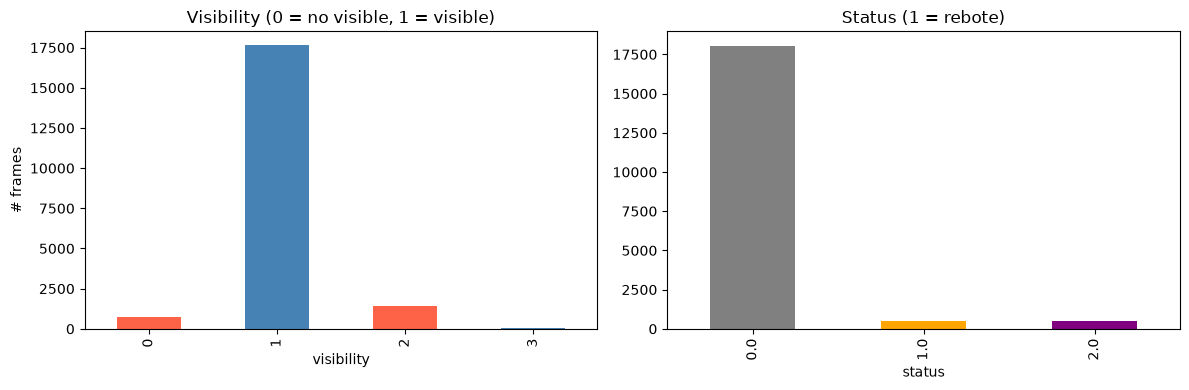

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels["visibility"].value_counts().sort_index().plot.bar(ax=axes[0], color=["tomato", "steelblue"])
axes[0].set_title("Visibility (0 = no visible, 1 = visible)")
axes[0].set_xlabel("visibility")
axes[0].set_ylabel("# frames")

labels["status"].value_counts().sort_index().plot.bar(ax=axes[1], color=["gray", "orange", "purple", "green"])
axes[1].set_title("Status (1 = rebote)")
axes[1].set_xlabel("status")
plt.tight_layout()
plt.show()

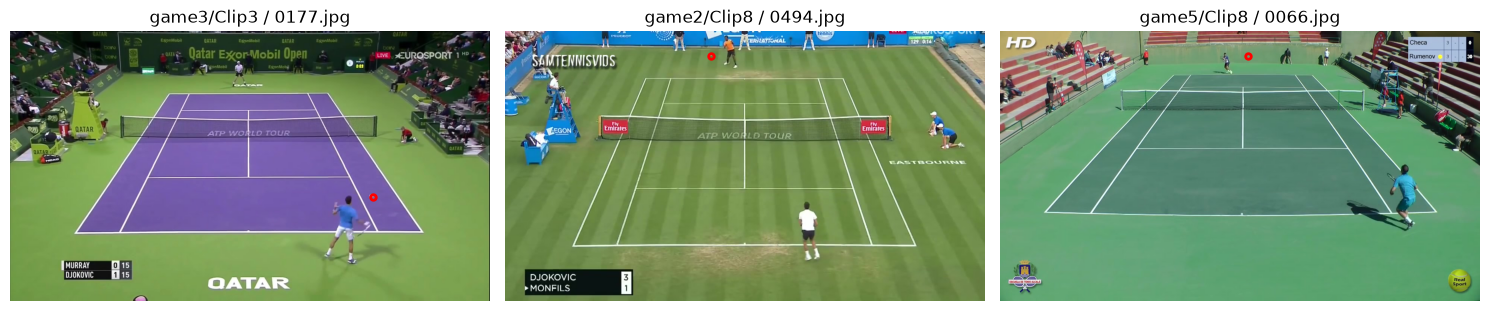

In [21]:
# 3 ejemplos de frames con pelota visible y su posición marcada
visible = labels[labels["visibility"] == 1].sample(3, random_state=RANDOM_SEED)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (_, row) in zip(axes, visible.iterrows()):
    img_path = DATASET_ROOT / row["clip"] / row["file name"]
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.plot(row["x-coordinate"], row["y-coordinate"], "o", markersize=4,
            markerfacecolor="none", markeredgecolor="red", markeredgewidth=2)
    ax.set_title(f"{row['clip']} / {row['file name']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Dataset PyTorch

Cada muestra:
- **Input:** 3 frames consecutivos `(t-2, t-1, t)` redimensionados a 640×360 y apilados como tensor `(9, H, W)` (RGB×3, normalizado a `[0, 1]`).
- **Output:** heatmap gaussiano `(1, H, W)` centrado en `(x, y)` del frame `t`, con σ=5px en la resolución de trabajo.

Se excluyen ventanas en las que algún frame de los 3 tenga `visibility=0`. El split 80/20 se hace **por clip completo** para evitar fugas.

In [22]:
def make_gaussian_heatmap(h, w, cx, cy, sigma):
    """Heatmap 2D gaussiano normalizado a [0, 1] (pico = 1)."""
    ys = np.arange(h, dtype=np.float32)[:, None]
    xs = np.arange(w, dtype=np.float32)[None, :]
    return np.exp(-((xs - cx) ** 2 + (ys - cy) ** 2) / (2.0 * sigma ** 2)).astype(np.float32)


class TrackNetDataset(Dataset):
    """Devuelve (input_9ch, heatmap_1ch, meta) para entrenamiento de TrackNet."""

    def __init__(self, samples, dataset_root, input_w, input_h, sigma, n_frames=3):
        self.samples = samples              # lista de dicts con info por muestra
        self.dataset_root = dataset_root
        self.input_w = input_w
        self.input_h = input_h
        self.sigma = sigma
        self.n_frames = n_frames

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        frames = []
        for fname in s["frame_files"]:
            img = cv2.imread(str(self.dataset_root / s["clip"] / fname))
            if img is None:
                raise FileNotFoundError(self.dataset_root / s["clip"] / fname)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            orig_h, orig_w = img.shape[:2]
            img = cv2.resize(img, (self.input_w, self.input_h), interpolation=cv2.INTER_AREA)
            frames.append(img.astype(np.float32) / 255.0)
        # (3 frames, H, W, 3) -> apilar canales -> (9, H, W)
        x = np.concatenate([f.transpose(2, 0, 1) for f in frames], axis=0)

        # Reescalar coordenadas de la pelota (del frame t) a la resolución de trabajo
        cx = s["x"] * (self.input_w / orig_w)
        cy = s["y"] * (self.input_h / orig_h)
        hm = make_gaussian_heatmap(self.input_h, self.input_w, cx, cy, self.sigma)

        return (
            torch.from_numpy(x),                       # (9, H, W)
            torch.from_numpy(hm).unsqueeze(0),         # (1, H, W)
            {"clip": s["clip"], "target_frame": s["frame_files"][-1]},
        )


def build_samples(clip_dirs, n_frames=3):
    """Construye la lista de muestras (ventanas de n_frames consecutivos con visibility=1 en todos)."""
    samples_by_clip = {}
    for clip_dir in clip_dirs:
        df = pd.read_csv(clip_dir / "Label.csv")
        df.columns = [c.strip() for c in df.columns]
        df = df.sort_values("file name").reset_index(drop=True)
        clip_key = f"{clip_dir.parent.name}/{clip_dir.name}"
        clip_samples = []
        for i in range(n_frames - 1, len(df)):
            window = df.iloc[i - n_frames + 1 : i + 1]
            if (window["visibility"] == 1).all():
                target = window.iloc[-1]
                clip_samples.append({
                    "clip": clip_key,
                    "frame_files": window["file name"].tolist(),
                    "x": float(target["x-coordinate"]),
                    "y": float(target["y-coordinate"]),
                    "status": int(target["status"]),
                })
        if clip_samples:
            samples_by_clip[clip_key] = clip_samples
    return samples_by_clip

samples_by_clip = build_samples(clip_dirs, n_frames=N_INPUT_FRAMES)
total_samples = sum(len(v) for v in samples_by_clip.values())
print(f"Clips con muestras: {len(samples_by_clip)}")
print(f"Muestras válidas (todas visibility=1 en la ventana): {total_samples}")

Clips con muestras: 95
Muestras válidas (todas visibility=1 en la ventana): 15586


In [23]:
# Split por clip (80/20) sin mezclar frames de un mismo clip entre splits
rng = random.Random(RANDOM_SEED)
all_clip_keys = sorted(samples_by_clip.keys())
rng.shuffle(all_clip_keys)
n_val_clips = max(1, int(round(len(all_clip_keys) * VAL_SPLIT)))
val_clips = set(all_clip_keys[:n_val_clips])
train_clips = set(all_clip_keys[n_val_clips:])

train_samples = [s for k in train_clips for s in samples_by_clip[k]]
val_samples = [s for k in val_clips for s in samples_by_clip[k]]
print(f"Clips train: {len(train_clips)} | muestras: {len(train_samples)}")
print(f"Clips val:   {len(val_clips)} | muestras: {len(val_samples)}")

train_ds = TrackNetDataset(train_samples, DATASET_ROOT, INPUT_W, INPUT_H, GAUSSIAN_SIGMA, N_INPUT_FRAMES)
val_ds = TrackNetDataset(val_samples, DATASET_ROOT, INPUT_W, INPUT_H, GAUSSIAN_SIGMA, N_INPUT_FRAMES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

x_sample, y_sample, _ = train_ds[0]
print(f"Tensor entrada: {tuple(x_sample.shape)} | heatmap: {tuple(y_sample.shape)} | pico HM: {y_sample.max():.3f}")

Clips train: 76 | muestras: 13209
Clips val:   19 | muestras: 2377
Tensor entrada: (9, 360, 640) | heatmap: (1, 360, 640) | pico HM: 1.000


## 4. Arquitectura TrackNet

Encoder **VGG16 preentrenado en ImageNet** adaptado a 9 canales de entrada (3 frames RGB apilados). La primera capa convolucional se reinicializa promediando los pesos originales triplicados para preservar el conocimiento preentrenado. Decoder U-Net con 4 bloques de upsampling y skip connections desde el encoder. Salida: 1 canal sigmoide del mismo tamaño que la entrada.

In [24]:
class TrackNetV2(nn.Module):
    """TrackNet con encoder VGG16 preentrenado adaptado a 9 canales de entrada."""

    def __init__(self, in_channels=9, out_channels=1):
        super().__init__()

        vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
        feats = list(vgg.features.children())

        # Adapt first conv: 3 -> in_channels, averaging pretrained weights
        orig_conv = feats[0]
        new_first = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        with torch.no_grad():
            new_first.weight.data = orig_conv.weight.data.repeat(1, 3, 1, 1) / 3.0
            new_first.bias.data = orig_conv.bias.data.clone()
        feats[0] = new_first

        # Encoder blocks — skip connections taken before each MaxPool
        self.enc1 = nn.Sequential(*feats[0:4])    # 64ch,  H×W
        self.pool1 = feats[4]
        self.enc2 = nn.Sequential(*feats[5:9])    # 128ch, H/2
        self.pool2 = feats[9]
        self.enc3 = nn.Sequential(*feats[10:16])  # 256ch, H/4
        self.pool3 = feats[16]
        self.enc4 = nn.Sequential(*feats[17:23])  # 512ch, H/8
        self.pool4 = feats[23]
        self.bottleneck = nn.Sequential(*feats[24:30])  # 512ch, H/16 (omit pool5)

        # Freeze all encoder except enc1[0] (first conv, adapts to 9ch)
        for name, param in self.enc1.named_parameters():
            if not name.startswith("0."):
                param.requires_grad = False
        for enc in [self.enc2, self.enc3, self.enc4, self.bottleneck]:
            for param in enc.parameters():
                param.requires_grad = False

        # Decoder: Upsample + 2×(Conv-BN-ReLU) with U-Net skip connections
        self.dec4 = self._conv_block(512 + 512, 512)
        self.dec3 = self._conv_block(512 + 256, 256)
        self.dec2 = self._conv_block(256 + 128, 128)
        self.dec1 = self._conv_block(128 + 64,  64)
        self.head = nn.Conv2d(64, out_channels, kernel_size=1)

    @staticmethod
    def _conv_block(in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        s3 = self.enc3(self.pool2(s2))
        s4 = self.enc4(self.pool3(s3))
        b  = self.bottleneck(self.pool4(s4))

        def up(t, ref):
            return F.interpolate(t, size=ref.shape[2:], mode="bilinear", align_corners=False)

        d4 = self.dec4(torch.cat([up(b,  s4), s4], dim=1))
        d3 = self.dec3(torch.cat([up(d4, s3), s3], dim=1))
        d2 = self.dec2(torch.cat([up(d3, s2), s2], dim=1))
        d1 = self.dec1(torch.cat([up(d2, s1), s1], dim=1))

        return torch.sigmoid(self.head(d1))


model = TrackNetV2(in_channels=3 * N_INPUT_FRAMES, out_channels=1).to(DEVICE)

total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = total - train_
print(f"Parámetros totales:     {total  / 1e6:.2f} M")
print(f"Parámetros entrenables: {train_ / 1e6:.2f} M")
print(f"Parámetros congelados:  {frozen / 1e6:.2f} M")
with torch.no_grad():
    dummy = torch.zeros(1, 9, INPUT_H, INPUT_W, device=DEVICE)
    print(f"Salida modelo (dummy): {tuple(model(dummy).shape)}")

Parámetros totales:     24.90 M
Parámetros entrenables: 10.19 M
Parámetros congelados:  14.71 M
Salida modelo (dummy): (1, 1, 360, 640)


## 5. Funciones de entrenamiento e inferencia

Esta sección solo **define** las funciones que se reutilizan después; no se entrena ningún modelo todavía. El único entrenamiento real del notebook ocurre en la sección 6 (grid search) — entrenar aquí un modelo "principal" con valores fijos para luego sustituirlo por el ganador del grid sería trabajo desechado.

**Entrenamiento** (`weighted_mse`, `run_epoch`, `train_model`):
- `weighted_mse`: MSE entre heatmap predicho y objetivo, con los píxeles positivos ponderados por `POS_WEIGHT` (la pelota ocupa pocos píxeles del frame; sin este peso el modelo aprendería trivialmente "todo es fondo").
- `train_model`: encapsula el entrenamiento en **dos fases** — fase 1 (solo decoder + primera conv del encoder, `lr=PHASE1_LR`, protege el encoder preentrenado de ImageNet de gradientes grandes de un decoder sin entrenar) y fase 2 (fine-tuning de todo el encoder, `lr` mucho más bajo, adapta las features al dominio "pelota de tenis" y reduce falsos positivos en torno al jugador). Aplica early stopping con patience `EARLY_STOPPING_PATIENCE` y guarda el mejor checkpoint.

**Inferencia** (`list_frames`, `predict_clip`, `evaluate_against_gt`):
- `predict_clip`: recorre un clip frame a frame y extrae `(x, y)` del heatmap predicho, con un filtro de continuidad temporal (picos locales + distancia al frame anterior) para evitar saltos lejanos por activaciones espúreas.
- `evaluate_against_gt`: compara las predicciones de un clip con su ground truth — distancia en píxeles, recall y tasa de falsos positivos. Es el criterio que usa el grid search (sección 6) para elegir la mejor combinación de hiperparámetros.

**Informes PDF** (`save_model_report_pdf`, `collect_example_frames`):
- `save_model_report_pdf`: genera un PDF de 5 páginas (hiperparámetros, arquitectura, curva de loss, métricas, ejemplos visuales) para **una** combinación del grid. Recibe `fixed_params`/`swept_params` como dicts arbitrarios — no asume cuántos ni qué hiperparámetros se barrieron, así que sigue funcionando si el grid de la sección 6 cambia de ejes en el futuro.
- `collect_example_frames`: prepara los frames de ejemplo (predicción vs ground truth) que se incrustan en el PDF.

In [25]:
def weighted_mse(pred, target, pos_weight=100.0):
    weight = 1.0 + (pos_weight - 1.0) * target
    return (weight * (pred - target) ** 2).mean()


def run_epoch(model, loader, train, opt, criterion, device, scaler, use_amp, log_every=10):
    model.train() if train else model.eval()
    total, n = 0.0, 0
    with (torch.enable_grad() if train else torch.no_grad()):
        for i, (x, y, _) in enumerate(loader):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                pred = model(x)
                loss = criterion(pred, y)
            if train:
                opt.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            total += loss.item() * x.size(0)
            n += x.size(0)
            if log_every and i % log_every == 0:
                print(f"  batch {i}/{len(loader)} | loss {loss.item():.5f}", flush=True)
    return total / max(n, 1)


def train_model(model, train_loader, val_loader, device, *, phase1_epochs, phase1_lr,
                 phase2_epochs, phase2_lr, pos_weight, patience, checkpoint_path,
                 extra_config=None, log_every=10, verbose=True):
    """Entrena TrackNet en dos fases y guarda el mejor checkpoint en checkpoint_path.

    Devuelve un dict con el historial de loss y el mejor val_loss alcanzado, para
    poder comparar configuraciones de hiperparámetros (grid search, sección 6).
    """
    criterion = lambda pred, target: weighted_mse(pred, target, pos_weight=pos_weight)
    use_amp = (device.type == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=phase1_lr)
    epochs = phase1_epochs + phase2_epochs
    current_phase = 1
    best_val = float("inf")
    patience_count = 0
    history = {"train": [], "val": []}

    for epoch in range(1, epochs + 1):
        if epoch == phase1_epochs + 1 and current_phase == 1:
            for param in model.parameters():
                param.requires_grad = True
            optimizer = torch.optim.Adam(model.parameters(), lr=phase2_lr)
            current_phase = 2
            if verbose:
                print(f"\n--- Fase 2: encoder descongelado, lr={phase2_lr} ---\n")

        t0 = time.time()
        tr = run_epoch(model, train_loader, True, optimizer, criterion, device, scaler, use_amp, log_every)
        va = run_epoch(model, val_loader, False, optimizer, criterion, device, scaler, use_amp, log_every)
        history["train"].append(tr)
        history["val"].append(va)
        dt = time.time() - t0
        if verbose:
            print(f"[Fase {current_phase}] Epoch {epoch:02d} | train {tr:.5f} | val {va:.5f} | {dt:.1f}s")

        if va < best_val:
            best_val = va
            patience_count = 0
            torch.save({
                "model_state": model.state_dict(),
                "epoch": epoch,
                "val_loss": va,
                "config": {
                    "input_w": INPUT_W, "input_h": INPUT_H,
                    "n_input_frames": N_INPUT_FRAMES, "sigma": GAUSSIAN_SIGMA,
                    "pos_weight": pos_weight, "phase1_lr": phase1_lr, "phase2_lr": phase2_lr,
                    **(extra_config or {}),
                },
            }, checkpoint_path)
            if verbose:
                print(f"  ↳ mejor val_loss, guardado en {Path(checkpoint_path).name}")
        else:
            patience_count += 1
            if patience_count >= patience:
                if verbose:
                    print(f"Early stopping en epoch {epoch} (patience={patience})")
                break

    if verbose:
        print(f"\nMejor val_loss: {best_val:.5f}")
    return {"history": history, "best_val": best_val, "checkpoint_path": checkpoint_path}

In [26]:
FRAME_RE = re.compile(r"^\d+\.jpg$", re.IGNORECASE)
TOP_K_PEAKS = 5  # nº de picos locales candidatos a evaluar por frame


def list_frames(clip_dir: Path):
    """Lista los frames de un clip (NNNN.jpg) ordenados numéricamente."""
    files = [p for p in clip_dir.iterdir() if FRAME_RE.match(p.name)]
    files.sort(key=lambda p: int(p.stem))
    return files


def load_and_prep(path: Path, out_w, out_h):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img.shape[:2]
    img_r = cv2.resize(img, (out_w, out_h), interpolation=cv2.INTER_AREA)
    return img_r.astype(np.float32) / 255.0, (orig_w, orig_h)


def find_local_peaks(hm, k, min_value, neighborhood=15):
    """Devuelve hasta k picos locales (y, x, valor) de un heatmap 2D, ordenados por valor desc."""
    local_max = (maximum_filter(hm, size=neighborhood) == hm) & (hm >= min_value)
    ys, xs = np.nonzero(local_max)
    if len(ys) == 0:
        return []
    vals = hm[ys, xs]
    order = np.argsort(vals)[::-1][:k]
    return [(int(ys[i]), int(xs[i]), float(vals[i])) for i in order]


def predict_clip(frame_paths, model, device, max_jump_px=MAX_JUMP_PX, top_k=TOP_K_PEAKS):
    """Predice (x, y) de la pelota por frame, con filtro de continuidad temporal.

    En vez de tomar siempre el argmax global del heatmap, se eligen los top_k
    picos locales y se prefiere el más cercano a la posición detectada en el
    frame anterior (dentro de max_jump_px, en resolución de trabajo). Esto evita
    que un blob espúreo lejano (líneas de la pista, jugador) con activación algo
    mayor sustituya a la detección real de un frame a otro. Se usa tanto para
    evaluar cada combinación del grid search (sección 6) como para la
    inferencia final sobre el clip de prueba (sección 7).
    """
    rows = []
    last3 = []
    prev_xy_work = None  # última posición válida, en resolución de trabajo (INPUT_W x INPUT_H)
    orig_w = orig_h = None
    for idx, fp in enumerate(frame_paths):
        img_r, (orig_w, orig_h) = load_and_prep(fp, INPUT_W, INPUT_H)
        last3.append(img_r)
        if len(last3) > N_INPUT_FRAMES:
            last3.pop(0)
        if len(last3) < N_INPUT_FRAMES:
            rows.append({"frame": idx, "file": fp.name, "ball_x": np.nan, "ball_y": np.nan,
                          "visibility": 0, "peak": 0.0})
            continue
        x = np.concatenate([f.transpose(2, 0, 1) for f in last3], axis=0)
        x_t = torch.from_numpy(x).unsqueeze(0).to(device)
        with torch.no_grad():
            hm = model(x_t)[0, 0].cpu().numpy()

        peaks = find_local_peaks(hm, top_k, HEATMAP_THRESHOLD)
        chosen = None
        if peaks:
            if prev_xy_work is not None:
                px, py = prev_xy_work
                in_range = [p for p in peaks if np.hypot(p[1] - px, p[0] - py) <= max_jump_px]
                chosen = max(in_range, key=lambda p: p[2]) if in_range else max(peaks, key=lambda p: p[2])
            else:
                chosen = max(peaks, key=lambda p: p[2])

        if chosen is not None:
            yy, xx, peak = chosen
            bx = float(xx) * (orig_w / INPUT_W)
            by = float(yy) * (orig_h / INPUT_H)
            vis = 1
            prev_xy_work = (xx, yy)
        else:
            bx, by, vis = np.nan, np.nan, 0
            peak = float(hm.max())
            # no se actualiza prev_xy_work: se mantiene la última posición conocida
        rows.append({"frame": idx, "file": fp.name, "ball_x": bx, "ball_y": by,
                      "visibility": vis, "peak": peak})
    return pd.DataFrame(rows)

In [27]:
def evaluate_against_gt(pred_df, gt_labels):
    """Compara predicciones con el ground truth de un clip (resolución original).

    Devuelve:
    - mean_dist_px / median_dist_px: distancia euclídea media/mediana en píxeles,
      calculada SOLO sobre frames con GT visible y pelota detectada por el modelo
      (no penaliza ni premia frames sin pelota real).
    - recall: % de frames con GT visible en los que el modelo detectó la pelota.
    - false_positive_rate: % de frames con GT NO visible en los que el modelo
      "alucinó" una detección (síntoma directo del problema de saltos/confusión
      con el jugador).
    """
    gt = gt_labels.set_index("file name")
    merged = pred_df.join(gt[["x-coordinate", "y-coordinate", "visibility"]].rename(
        columns={"x-coordinate": "gt_x", "y-coordinate": "gt_y", "visibility": "gt_visibility"}),
        on="file")

    gt_visible = merged["gt_visibility"] == 1
    both_visible = gt_visible & (merged["visibility"] == 1)

    dists = np.hypot(merged.loc[both_visible, "ball_x"] - merged.loc[both_visible, "gt_x"],
                      merged.loc[both_visible, "ball_y"] - merged.loc[both_visible, "gt_y"])

    gt_not_visible = ~gt_visible
    false_positives = gt_not_visible & (merged["visibility"] == 1)

    return {
        "n_frames": len(merged),
        "n_gt_visible": int(gt_visible.sum()),
        "n_both_visible": int(both_visible.sum()),
        "mean_dist_px": float(dists.mean()) if len(dists) else float("nan"),
        "median_dist_px": float(dists.median()) if len(dists) else float("nan"),
        "recall": float((merged.loc[gt_visible, "visibility"] == 1).mean()) if gt_visible.sum() else float("nan"),
        "false_positive_rate": float(false_positives.sum() / max(gt_not_visible.sum(), 1)),
    }

In [28]:
from matplotlib.backends.backend_pdf import PdfPages


def _page_text(pdf, title, lines, fontsize=11):
    """Página de PDF con un título y una lista de líneas de texto (clave: valor)."""
    fig = plt.figure(figsize=(8.27, 11.69))  # A4
    fig.suptitle(title, fontsize=16, fontweight="bold", y=0.97)
    fig.text(0.08, 0.90, "\n".join(lines), fontsize=fontsize, family="monospace",
              va="top", ha="left")
    pdf.savefig(fig)
    plt.close(fig)


def _page_table(pdf, title, df, fontsize=8):
    """Página de PDF con una tabla a partir de un DataFrame."""
    fig, ax = plt.subplots(figsize=(11.69, 8.27))  # A4 horizontal, más ancho para tablas
    fig.suptitle(title, fontsize=16, fontweight="bold")
    ax.axis("off")
    tbl = ax.table(cellText=df.values, colLabels=df.columns, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.auto_set_column_width(col=list(range(len(df.columns))))
    pdf.savefig(fig)
    plt.close(fig)


def save_model_report_pdf(pdf_path, *, tag, fixed_params, swept_params, arch_summary,
                           history, phase1_epochs, eval_metrics, example_frames=None):
    """Genera un PDF con el informe completo de UNA combinación del grid search.

    No asume nada sobre cuántos ni qué hiperparámetros se barrieron: swept_params
    y fixed_params son dicts arbitrarios {nombre: valor}, así que esta función
    sirve igual si el grid cambia de ejes en el futuro.

    Páginas: (1) hiperparámetros de esta combinación + fijos, (2) arquitectura,
    (3) curva de loss train/val, (4) tabla de métricas de evaluación,
    (5) ejemplos visuales predicción vs GT (si se pasan).
    """
    pdf_path = Path(pdf_path)
    pdf_path.parent.mkdir(parents=True, exist_ok=True)

    with PdfPages(pdf_path) as pdf:
        # 1. Hiperparámetros
        lines = [f"Combinación: {tag}", "", "Hiperparámetros de ESTA combinación (barridos en el grid):"]
        lines += [f"  {k:25s} = {v}" for k, v in swept_params.items()]
        lines += ["", "Hiperparámetros fijos (iguales en todas las combinaciones):"]
        lines += [f"  {k:25s} = {v}" for k, v in fixed_params.items()]
        _page_text(pdf, "Hiperparámetros", lines)

        # 2. Arquitectura
        _page_text(pdf, "Arquitectura", [f"  {k:25s} = {v}" for k, v in arch_summary.items()])

        # 3. Curva de loss
        fig, ax = plt.subplots(figsize=(8.27, 6))
        epochs_range = range(1, len(history["train"]) + 1)
        ax.plot(epochs_range, history["train"], label="train")
        ax.plot(epochs_range, history["val"], label="val")
        ax.axvline(phase1_epochs, color="gray", linestyle=":", linewidth=1, label="fin fase 1")
        ax.set_xlabel("epoch")
        ax.set_ylabel("MSE loss (weighted)")
        ax.set_title(f"Curva de entrenamiento — {tag}")
        ax.legend()
        ax.grid(alpha=0.3)
        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

        # 4. Métricas de evaluación (distancia, recall, FP rate — "accuracy" del problema)
        metrics_lines = ["Métricas de evaluación sobre clips de validación:", ""]
        metrics_lines += [f"  {k:25s} = {v:.4f}" if isinstance(v, float) else f"  {k:25s} = {v}"
                           for k, v in eval_metrics.items()]
        _page_text(pdf, "Métricas", metrics_lines)

        # 5. Ejemplos visuales (opcional)
        if example_frames:
            fig, axes = plt.subplots(1, len(example_frames), figsize=(4 * len(example_frames), 4))
            if len(example_frames) == 1:
                axes = [axes]
            for ax, (img, pred_xy, gt_xy, frame_name) in zip(axes, example_frames):
                ax.imshow(img)
                if pred_xy is not None:
                    ax.plot(*pred_xy, "o", markersize=12, markerfacecolor="none",
                            markeredgecolor="red", markeredgewidth=2, label="pred")
                if gt_xy is not None:
                    ax.plot(*gt_xy, "x", markersize=12, markeredgecolor="lime",
                            markeredgewidth=2, label="gt")
                ax.set_title(frame_name, fontsize=9)
                ax.axis("off")
                ax.legend(loc="upper right", fontsize=7)
            fig.suptitle(f"Ejemplos predicción vs ground truth — {tag}")
            fig.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

    return pdf_path


def collect_example_frames(clip_dir, pred_df, gt_labels, n=3):
    """Selecciona n frames con GT visible y devuelve tuplas listas para el PDF."""
    valid = pred_df[pred_df["visibility"] == 1]
    if valid.empty:
        return []
    idx = np.linspace(0, len(valid) - 1, num=min(n, len(valid)), dtype=int)
    out = []
    gt_idx = gt_labels.set_index("file name")
    for i in idx:
        row = valid.iloc[i]
        img = cv2.cvtColor(cv2.imread(str(clip_dir / row["file"])), cv2.COLOR_BGR2RGB)
        pred_xy = (row["ball_x"], row["ball_y"])
        gt_xy = None
        if row["file"] in gt_idx.index:
            gt_row = gt_idx.loc[row["file"]]
            if gt_row["visibility"] == 1:
                gt_xy = (gt_row["x-coordinate"], gt_row["y-coordinate"])
        out.append((img, pred_xy, gt_xy, row["file"]))
    return out

In [29]:
def _emit_figure(fig, pdf=None):
    """Muestra una figura en pantalla y, si se pasa un PdfPages abierto, la añade al PDF."""
    if pdf is not None:
        pdf.savefig(fig)
    plt.show()
    plt.close(fig)


def build_comparison_report(grid_results, grid_histories, sweep_cols, *, fixed_params,
                             arch_summary, phase1_epochs, pdf=None):
    """Genera (e imprime/plotea) el informe comparativo de TODAS las combinaciones del grid.

    Genérico por nombre de columna vía sweep_cols (lista de 1 o 2 nombres de
    columnas de grid_results que se barrieron) — no asume cuántas combinaciones
    hay ni sus valores concretos, así que sirve igual si el grid cambia de ejes.
    Si se pasa un objeto PdfPages abierto en `pdf`, además vuelca cada figura al
    PDF; si no, solo imprime/plotea en pantalla. Devuelve report_df (tabla final).
    """
    print("=" * 70)
    print("HIPERPARÁMETROS FIJOS (iguales en todas las combinaciones)")
    print("=" * 70)
    fixed_lines = [f"  {k:25s} = {v}" for k, v in fixed_params.items()]
    for line in fixed_lines:
        print(line)

    print("\n" + "=" * 70)
    print("HIPERPARÁMETROS BARRIDOS")
    print("=" * 70)
    swept_lines = [f"  {col:20s} = {sorted(grid_results[col].unique())}" for col in sweep_cols]
    for line in swept_lines:
        print(line)
    print(f"  Combinaciones totales: {len(grid_results)}")

    print("\n" + "=" * 70)
    print("ARQUITECTURA")
    print("=" * 70)
    arch_lines = [f"  {k:25s} = {v}" for k, v in arch_summary.items()]
    for line in arch_lines:
        print(line)

    print("\n" + "=" * 70)
    print("RESULTADOS POR COMBINACIÓN (ordenados por distancia media al GT)")
    print("=" * 70)
    report_df = grid_results[["tag"] + sweep_cols + ["epochs_run", "best_val_loss",
                              "mean_dist_px", "recall", "false_positive_rate"]].copy()
    report_df["recall_%"] = (report_df.pop("recall") * 100).round(1)
    report_df["fp_rate_%"] = (report_df.pop("false_positive_rate") * 100).round(1)
    report_df["mean_dist_px"] = report_df["mean_dist_px"].round(2)
    report_df["best_val_loss"] = report_df["best_val_loss"].round(5)
    print(report_df.to_string(index=False))

    winner_tag = grid_results.iloc[0]["tag"]
    worst_row = grid_results.iloc[-1]
    winner_row = grid_results.iloc[0]
    improvement_pct = (100 * (worst_row["mean_dist_px"] - winner_row["mean_dist_px"])
                       / max(worst_row["mean_dist_px"], 1e-9))
    conclusion_lines = [
        f"Ganador: {winner_tag} (dist_media={winner_row['mean_dist_px']:.2f}px, "
        f"recall={winner_row['recall']*100:.1f}%, FP_rate={winner_row['false_positive_rate']*100:.1f}%)",
        f"Peor combinación: {worst_row['tag']} (dist_media={worst_row['mean_dist_px']:.2f}px)",
        f"El ganador mejora un {improvement_pct:.1f}% la distancia media frente a la peor combinación probada.",
    ]
    for col in sweep_cols:
        corr = grid_results[col].astype(float).corr(grid_results["mean_dist_px"])
        if not np.isnan(corr):
            conclusion_lines.append(f"Correlación {col} vs distancia media: {corr:+.2f}")
    print("\n" + "=" * 70)
    print("CONCLUSIÓN")
    print("=" * 70)
    for line in conclusion_lines:
        print(f"  {line}")

    if pdf is not None:
        _page_text(pdf, "Resumen del grid search",
                   ["Hiperparámetros fijos:", ""] + fixed_lines +
                   ["", "Hiperparámetros barridos:", ""] + swept_lines +
                   [f"  Combinaciones totales: {len(grid_results)}"])
        _page_text(pdf, "Arquitectura", arch_lines)
        _page_table(pdf, "Resultados por combinación", report_df)
        _page_text(pdf, "Conclusión", conclusion_lines)

    # Curvas de aprendizaje en grid de subplots (forma = nº valores únicos por eje).
    axis_a_vals = sorted(grid_results[sweep_cols[0]].unique())
    axis_b_vals = sorted(grid_results[sweep_cols[1]].unique()) if len(sweep_cols) > 1 else [None]
    n_rows, n_cols = len(axis_a_vals), max(len(axis_b_vals), 1)
    fig_curves, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3 * n_rows),
                                     sharey=True, squeeze=False)
    for i, a_val in enumerate(axis_a_vals):
        for j, b_val in enumerate(axis_b_vals):
            mask = grid_results[sweep_cols[0]] == a_val
            if len(sweep_cols) > 1:
                mask &= grid_results[sweep_cols[1]] == b_val
            match = grid_results[mask]
            ax = axes[i][j]
            if match.empty:
                ax.axis("off")
                continue
            tag = match.iloc[0]["tag"]
            hist = grid_histories[tag]
            epochs_range = range(1, len(hist["train"]) + 1)
            ax.plot(epochs_range, hist["train"], label="train")
            ax.plot(epochs_range, hist["val"], label="val")
            ax.axvline(phase1_epochs, color="gray", linestyle=":", linewidth=1)
            title = f"{sweep_cols[0]}={a_val:g}"
            if len(sweep_cols) > 1:
                title += f", {sweep_cols[1]}={b_val:g}"
            if tag == winner_tag:
                title += " ★"
                for spine in ax.spines.values():
                    spine.set_edgecolor("green")
                    spine.set_linewidth(2.5)
            ax.set_title(title, fontsize=9)
            ax.set_xlabel("epoch")
            if j == 0:
                ax.set_ylabel("MSE loss")
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)
    fig_curves.suptitle("Curvas de aprendizaje por combinación (línea punteada = fin de fase 1)", y=1.02)
    fig_curves.tight_layout()
    _emit_figure(fig_curves, pdf)

    # Curvas de val_loss superpuestas (todas en un mismo eje).
    fig_overlay, ax = plt.subplots(figsize=(9, 6))
    for _, row in grid_results.iterrows():
        hist = grid_histories[row["tag"]]
        style = "-" if row["tag"] == winner_tag else "--"
        lw = 2.5 if row["tag"] == winner_tag else 1
        ax.plot(range(1, len(hist["val"]) + 1), hist["val"], style, linewidth=lw,
                label=row["tag"] + (" ★" if row["tag"] == winner_tag else ""))
    ax.axvline(phase1_epochs, color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("epoch")
    ax.set_ylabel("val_loss")
    ax.set_title("Val loss superpuesto — todas las combinaciones")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    fig_overlay.tight_layout()
    _emit_figure(fig_overlay, pdf)

    # Heatmaps de métricas vs los 2 ejes barridos (solo si hay exactamente 2 ejes numéricos).
    if len(sweep_cols) == 2:
        fig_heatmaps, hm_axes = plt.subplots(1, 3, figsize=(15, 4))
        for ax, metric, cmap in zip(hm_axes, ["mean_dist_px", "recall", "false_positive_rate"],
                                     ["viridis_r", "viridis", "viridis_r"]):
            pivot = grid_results.pivot(index=sweep_cols[0], columns=sweep_cols[1], values=metric)
            im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels([f"{c:g}" for c in pivot.columns])
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels([f"{r:g}" for r in pivot.index])
            ax.set_xlabel(sweep_cols[1])
            ax.set_ylabel(sweep_cols[0])
            ax.set_title(metric)
            for yi in range(pivot.shape[0]):
                for xi in range(pivot.shape[1]):
                    val = pivot.values[yi, xi]
                    if not np.isnan(val):
                        ax.text(xi, yi, f"{val:.2f}", ha="center", va="center", fontsize=8, color="white")
            plt.colorbar(im, ax=ax, fraction=0.046)
        fig_heatmaps.suptitle("Heatmaps de métricas sobre el espacio de hiperparámetros")
        fig_heatmaps.tight_layout()
        _emit_figure(fig_heatmaps, pdf)

    # Scatter trade-off recall vs distancia, coloreado por tasa de falsos positivos.
    fig_tradeoff, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(grid_results["mean_dist_px"], grid_results["recall"] * 100,
                     c=grid_results["false_positive_rate"] * 100, cmap="coolwarm",
                     s=120, edgecolor="black")
    for _, row in grid_results.iterrows():
        ax.annotate(row["tag"], (row["mean_dist_px"], row["recall"] * 100),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("Distancia media al GT (px)")
    ax.set_ylabel("Recall (%)")
    ax.set_title("Trade-off recall vs distancia (color = tasa de falsos positivos %)")
    plt.colorbar(sc, ax=ax, label="FP rate (%)")
    ax.grid(alpha=0.3)
    fig_tradeoff.tight_layout()
    _emit_figure(fig_tradeoff, pdf)

    return report_df


def save_comparison_report_pdf(pdf_path, grid_results, grid_histories, sweep_cols, **kwargs):
    """Abre un PdfPages en pdf_path y delega en build_comparison_report."""
    pdf_path = Path(pdf_path)
    pdf_path.parent.mkdir(parents=True, exist_ok=True)
    with PdfPages(pdf_path) as pdf:
        report_df = build_comparison_report(grid_results, grid_histories, sweep_cols, pdf=pdf, **kwargs)
    return pdf_path, report_df

## 6. Grid search y selección del modelo final

Este es el **único entrenamiento real** del notebook: se prueban 6 combinaciones de `(PHASE2_LR, PHASE2_EPOCHS)` — la fase de fine-tuning del encoder — y la que obtenga menor distancia media al ground truth se promueve a `BEST_MODEL_PATH`. No hay un entrenamiento "principal" previo que luego se descarte.

**Qué se barre:** `PHASE2_LR_GRID = [1e-6, 1e-5]` × `PHASE2_EPOCHS_GRID = [4, 7, 10]` (2×3 = 6 combinaciones). `phase2_lr` se recortó a 2 valores conservadores para acotar el coste total en tiempo — es el eje más sensible (puede destruir el preentrenamiento de ImageNet si es muy alto), así que se prioriza no arriesgar con valores más agresivos en este primer grid.

**Qué queda fijo:** `PHASE1_EPOCHS=6`/`PHASE1_LR` (warmup del decoder, igual en las 6 combinaciones; reducido de 10 a 6 épocas para recortar tiempo total), `POS_WEIGHT`, `GAUSSIAN_SIGMA`, `BATCH_SIZE`. `EARLY_STOPPING_PATIENCE=3` se aplica dentro de cada combinación.

**Evaluación:** cada combinación se mide con `evaluate_against_gt` sobre 5 clips de validación fijos (`GRID_EVAL_CLIPS`, no vistos en entrenamiento) — distancia media en píxeles, recall y tasa de falsos positivos.

**Informe generado:** tabla de hiperparámetros fijos y barridos, resumen de arquitectura (parámetros totales/entrenables/congelados), tabla de métricas de las 6 combinaciones, y las curvas de aprendizaje (train/val loss) de cada una, con la ganadora resaltada — todo para poder justificar la elección final ante el tribunal sin tener que rehacer el experimento.

**Coste:** `PHASE1_EPOCHS (6) × 6 combinaciones + suma(PHASE2_EPOCHS_GRID) × 2 valores de LR` = `36 + 21×2 = 78` épocas en total (antes de early stopping) — pensado para acabar en torno a las 4h en la pod de RunPod (L4, 6 vCPU), frente a las ~7h de la versión anterior con 9 combinaciones y `PHASE1_EPOCHS=10`.

In [30]:
# ----- Grid de hiperparámetros a comparar -----
# phase2_epochs mantiene 3 valores dispares (infraentrenado / intermedio /
# rendimientos decrecientes). phase2_lr se recorta a 2 valores conservadores
# (1e-6, 1e-5): es el eje más sensible (puede destruir el preentrenamiento de
# ImageNet si es muy alto), así que se prioriza no arriesgar con 1e-4 en este
# primer grid acotado en tiempo; si 1e-5 gana claramente sobre 1e-6, eso ya
# indica si merece la pena explorar valores más altos en un grid futuro.
PHASE2_LR_GRID = [1e-6, 1e-5]
PHASE2_EPOCHS_GRID = [4, 7, 10]

# Clips de validación (no usados en train) sobre los que se mide distancia/recall.
# Se reutilizan val_clips del split 80/20 ya calculado en la sección 3.
GRID_EVAL_CLIPS = sorted(val_clips)[:5]

GRID_MODELS_DIR = MODELS_OUT / "grid_search"
GRID_MODELS_DIR.mkdir(parents=True, exist_ok=True)
GRID_REPORTS_DIR = MODELS_OUT / "informes"
GRID_REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Hiperparámetros fijos en TODAS las combinaciones (para los PDF). Mantenerlo
# separado de los "swept" de cada combinación, que se construyen dentro del
# bucle a partir de los argumentos de run_grid_search (no hardcodeados).
FIXED_PARAMS_FOR_REPORT = {
    "PHASE1_EPOCHS": PHASE1_EPOCHS, "PHASE1_LR": PHASE1_LR,
    "POS_WEIGHT": POS_WEIGHT, "GAUSSIAN_SIGMA": GAUSSIAN_SIGMA,
    "BATCH_SIZE": BATCH_SIZE, "EARLY_STOPPING_PATIENCE": EARLY_STOPPING_PATIENCE,
    "N_INPUT_FRAMES": N_INPUT_FRAMES, "INPUT_SIZE": f"{INPUT_W}x{INPUT_H}",
}
ARCH_SUMMARY_FOR_REPORT = {
    "Modelo": "TrackNetV2 (encoder VGG16 + decoder U-Net)",
    "Parámetros totales (M)": round(total / 1e6, 2),
    "Entrenables en fase 1 (M)": round(train_ / 1e6, 2),
    "Congelados en fase 1 (M)": round(frozen / 1e6, 2),
}


def evaluate_model_on_clips(model, device, clip_keys, dataset_root):
    """Promedia distancia/recall de evaluate_against_gt sobre varios clips."""
    all_metrics = []
    for clip_key in clip_keys:
        clip_dir = dataset_root / clip_key
        frames = list_frames(clip_dir)
        gt = pd.read_csv(clip_dir / "Label.csv")
        gt.columns = [c.strip() for c in gt.columns]
        pred = predict_clip(frames, model, device)
        all_metrics.append(evaluate_against_gt(pred, gt))
    df = pd.DataFrame(all_metrics)
    # Media ponderada por nº de frames con GT visible de cada clip.
    w = df["n_gt_visible"].clip(lower=1)
    return {
        "mean_dist_px": float((df["mean_dist_px"] * w).sum() / w.sum()),
        "recall": float((df["recall"] * w).sum() / w.sum()),
        "false_positive_rate": float(df["false_positive_rate"].mean()),
    }


def run_grid_search(phase2_lr_grid, phase2_epochs_grid):
    """Entrena una combinación por cada (phase2_lr, phase2_epochs) y las evalúa.

    phase1_epochs/phase1_lr/pos_weight quedan fijos (los de la sección 1) en
    todas las combinaciones; solo varía el fine-tuning del encoder (fase 2).
    Por cada combinación genera además un PDF individual con su informe
    completo (sección 5: save_model_report_pdf), guardado en GRID_REPORTS_DIR.
    Devuelve (tabla_resultados, historias_por_combinación) para el informe
    comparativo global (siguiente celda).

    verbose=True (log_every=0) en train_model: imprime el progreso por época
    (train/val loss + tiempo) en vez de quedarse en silencio hasta acabar toda
    la combinación, que con varias épocas puede tardar minutos sin dar señales
    de vida. Además se imprime aquí el progreso global (combinación N/total,
    tiempo transcurrido y ETA estimado a partir de la media de duración de las
    combinaciones ya completadas).
    """
    rows = []
    histories = {}
    example_clip_dir = DATASET_ROOT / GRID_EVAL_CLIPS[0] if GRID_EVAL_CLIPS else None

    combos = [(lr, ep) for lr in phase2_lr_grid for ep in phase2_epochs_grid]
    total_combos = len(combos)
    grid_t0 = time.time()
    combo_durations = []

    for combo_idx, (phase2_lr, phase2_epochs) in enumerate(combos, start=1):
        tag = f"lr{phase2_lr:g}_ep{phase2_epochs}"
        elapsed_min = (time.time() - grid_t0) / 60
        eta_msg = ""
        if combo_durations:
            avg_dur = sum(combo_durations) / len(combo_durations)
            remaining = avg_dur * (total_combos - combo_idx + 1) / 60
            eta_msg = f" | transcurrido {elapsed_min:.1f}min | ETA restante ~{remaining:.1f}min"
        print(f"\n{'='*60}\nCombinación {combo_idx}/{total_combos}: "
              f"phase2_lr={phase2_lr} | phase2_epochs={phase2_epochs}{eta_msg}\n{'='*60}", flush=True)
        combo_t0 = time.time()

        torch.manual_seed(RANDOM_SEED)  # misma inicialización de decoder en cada combinación
        grid_model = TrackNetV2(in_channels=3 * N_INPUT_FRAMES, out_channels=1).to(DEVICE)
        ckpt_path = GRID_MODELS_DIR / f"tracknet_{tag}.pth"

        # swept_params: SOLO lo que varía en esta llamada, genérico (no
        # hardcodea "phase2_lr"/"phase2_epochs" como strings sueltos en
        # ningún otro sitio del informe) — si el grid cambia de ejes en el
        # futuro, basta con cambiar este dict y el resto sigue funcionando.
        swept_params = {"phase2_lr": phase2_lr, "phase2_epochs": phase2_epochs}

        result = train_model(
            grid_model, train_loader, val_loader, DEVICE,
            phase1_epochs=PHASE1_EPOCHS, phase1_lr=PHASE1_LR,
            phase2_epochs=phase2_epochs, phase2_lr=phase2_lr,
            pos_weight=POS_WEIGHT, patience=EARLY_STOPPING_PATIENCE,
            checkpoint_path=ckpt_path,
            extra_config={"grid_tag": tag}, log_every=0, verbose=True,
        )
        histories[tag] = result["history"]

        grid_model.eval()
        eval_metrics = evaluate_model_on_clips(grid_model, DEVICE, GRID_EVAL_CLIPS, DATASET_ROOT)
        rows.append({
            "tag": tag, "phase2_lr": phase2_lr, "phase2_epochs": phase2_epochs,
            "epochs_run": len(result["history"]["val"]),
            "best_val_loss": result["best_val"],
            **eval_metrics,
            "checkpoint": str(ckpt_path),
        })
        print(f"  best_val_loss={result['best_val']:.5f} | "
              f"dist_media={eval_metrics['mean_dist_px']:.2f}px | "
              f"recall={eval_metrics['recall']*100:.1f}% | "
              f"FP_rate={eval_metrics['false_positive_rate']*100:.1f}%", flush=True)

        # PDF individual de esta combinación.
        example_frames = []
        if example_clip_dir is not None:
            ex_frames = list_frames(example_clip_dir)
            ex_gt = pd.read_csv(example_clip_dir / "Label.csv")
            ex_gt.columns = [c.strip() for c in ex_gt.columns]
            ex_pred = predict_clip(ex_frames, grid_model, DEVICE)
            example_frames = collect_example_frames(example_clip_dir, ex_pred, ex_gt, n=3)
        save_model_report_pdf(
            GRID_REPORTS_DIR / f"{tag}.pdf",
            tag=tag, fixed_params=FIXED_PARAMS_FOR_REPORT, swept_params=swept_params,
            arch_summary=ARCH_SUMMARY_FOR_REPORT, history=result["history"],
            phase1_epochs=PHASE1_EPOCHS, eval_metrics=eval_metrics,
            example_frames=example_frames,
        )
        combo_dur = time.time() - combo_t0
        combo_durations.append(combo_dur)
        print(f"  ↳ informe PDF guardado en {GRID_REPORTS_DIR / f'{tag}.pdf'} "
              f"(combinación completada en {combo_dur/60:.1f}min)", flush=True)

    total_min = (time.time() - grid_t0) / 60
    print(f"\n{'='*60}\nGrid search completo: {total_combos} combinaciones en {total_min:.1f}min\n{'='*60}", flush=True)

    df = pd.DataFrame(rows).sort_values("mean_dist_px").reset_index(drop=True)
    return df, histories


grid_results, grid_histories = run_grid_search(PHASE2_LR_GRID, PHASE2_EPOCHS_GRID)
grid_results


Combinación 1/6: phase2_lr=1e-06 | phase2_epochs=4
[Fase 1] Epoch 01 | train 0.02418 | val 0.00444 | 449.4s
  ↳ mejor val_loss, guardado en tracknet_lr1e-06_ep4.pth
[Fase 1] Epoch 02 | train 0.00236 | val 0.00272 | 305.7s
  ↳ mejor val_loss, guardado en tracknet_lr1e-06_ep4.pth
[Fase 1] Epoch 03 | train 0.00142 | val 0.00245 | 300.6s
  ↳ mejor val_loss, guardado en tracknet_lr1e-06_ep4.pth
[Fase 1] Epoch 04 | train 0.00109 | val 0.00222 | 324.4s
  ↳ mejor val_loss, guardado en tracknet_lr1e-06_ep4.pth
[Fase 1] Epoch 05 | train 0.00096 | val 0.00256 | 298.2s
[Fase 1] Epoch 06 | train 0.00081 | val 0.00224 | 296.7s

--- Fase 2: encoder descongelado, lr=1e-06 ---

[Fase 2] Epoch 07 | train 0.00060 | val 0.00224 | 309.8s
Early stopping en epoch 7 (patience=3)

Mejor val_loss: 0.00222
  best_val_loss=0.00222 | dist_media=5.34px | recall=93.4% | FP_rate=50.9%
  ↳ informe PDF guardado en /workspace/TFM/outputs/grid_models/informes/lr1e-06_ep4.pdf (combinación completada en 38.8min)

Combinac

,tag,phase2_lr,phase2_epochs,epochs_run,best_val_loss,mean_dist_px,recall,false_positive_rate,checkpoint
0,lr1e-05_ep4,0.000010,4,10,0.002199,3.461979,0.900302,0.411923,/workspace/TFM/outputs/grid_models/grid_search...
1,lr1e-05_ep10,0.000010,10,9,0.001983,3.883765,0.924471,0.454245,/workspace/TFM/outputs/grid_models/grid_search...
2,lr1e-05_ep7,0.000010,7,9,0.001847,4.156371,0.921450,0.491401,/workspace/TFM/outputs/grid_models/grid_search...
3,lr1e-06_ep7,0.000001,7,9,0.002120,5.055304,0.909366,0.558934,/workspace/TFM/outputs/grid_models/grid_search...
4,lr1e-06_ep10,0.000001,10,9,0.001964,5.096141,0.930514,0.500433,/workspace/TFM/outputs/grid_models/grid_search...
5,lr1e-06_ep4,0.000001,4,7,0.002217,5.343949,0.933535,0.508678,/workspace/TFM/outputs/grid_models/grid_search...


HIPERPARÁMETROS FIJOS (iguales en todas las combinaciones)
  PHASE1_EPOCHS             = 6
  PHASE1_LR                 = 0.001
  POS_WEIGHT                = 100.0
  GAUSSIAN_SIGMA            = 5.0
  BATCH_SIZE                = 32
  EARLY_STOPPING_PATIENCE   = 3
  N_INPUT_FRAMES            = 3
  INPUT_SIZE                = 640x360

HIPERPARÁMETROS BARRIDOS
  phase2_lr            = [np.float64(1e-06), np.float64(1e-05)]
  phase2_epochs        = [np.int64(4), np.int64(7), np.int64(10)]
  Combinaciones totales: 6

ARQUITECTURA
  Modelo                    = TrackNetV2 (encoder VGG16 + decoder U-Net)
  Parámetros totales (M)    = 24.9
  Entrenables en fase 1 (M) = 10.19
  Congelados en fase 1 (M)  = 14.71

RESULTADOS POR COMBINACIÓN (ordenados por distancia media al GT)
         tag  phase2_lr  phase2_epochs  epochs_run  best_val_loss  mean_dist_px  recall_%  fp_rate_%
 lr1e-05_ep4   0.000010              4          10        0.00220          3.46      90.0       41.2
lr1e-05_ep10   0.000010

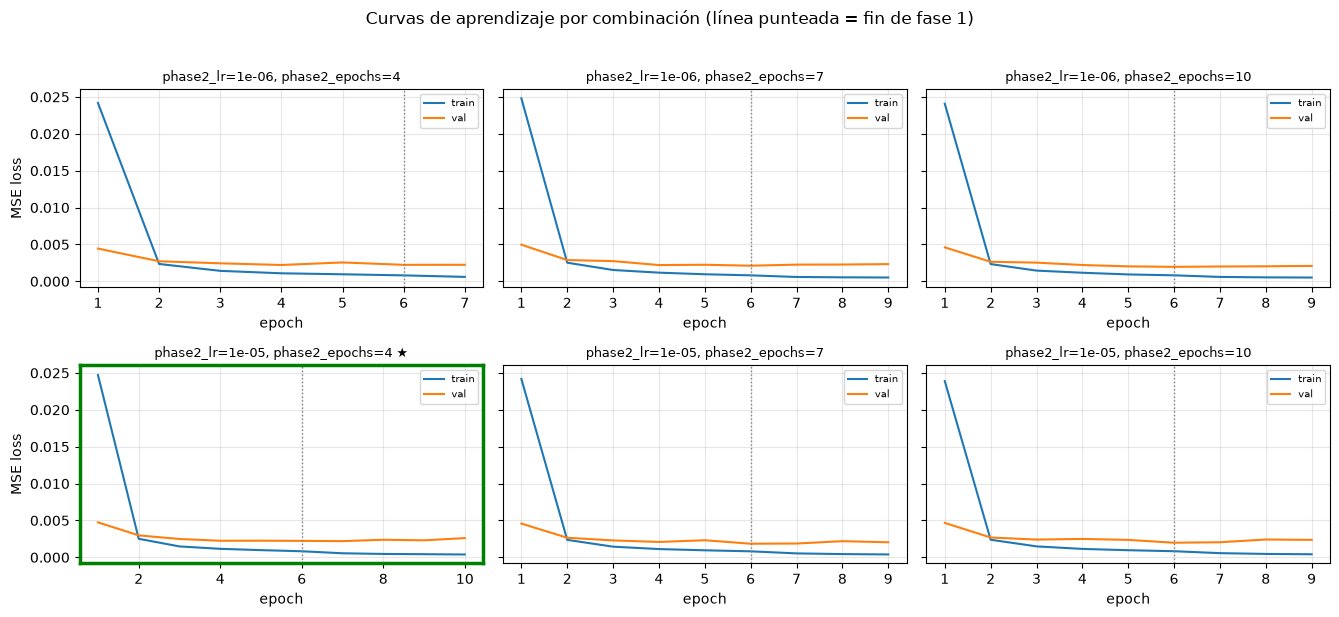

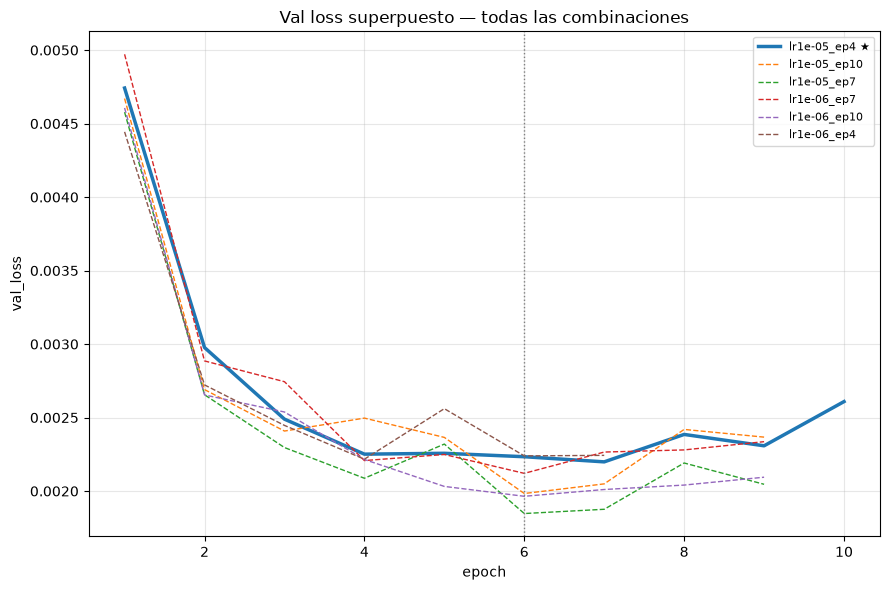

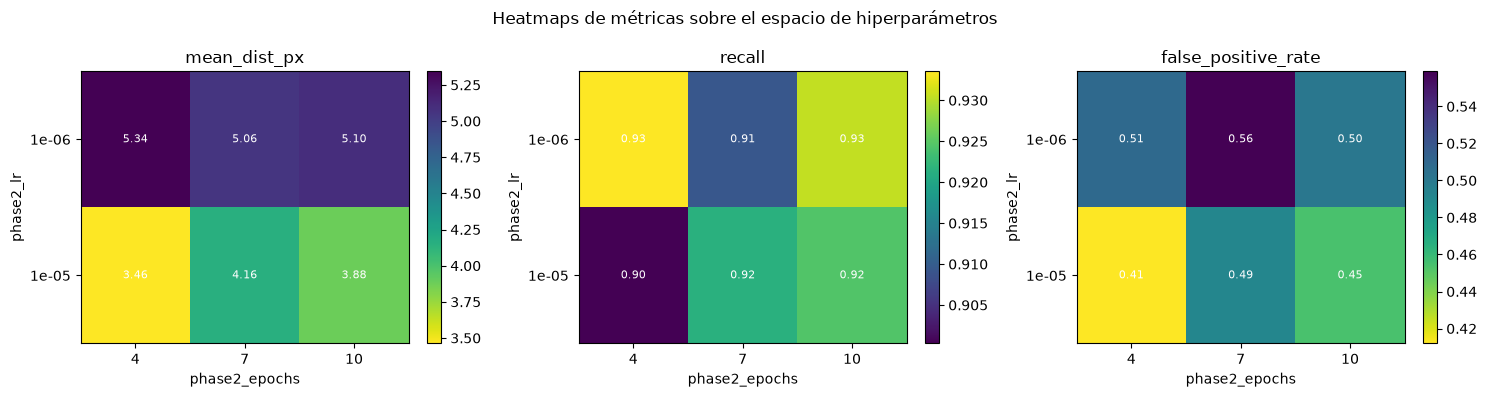

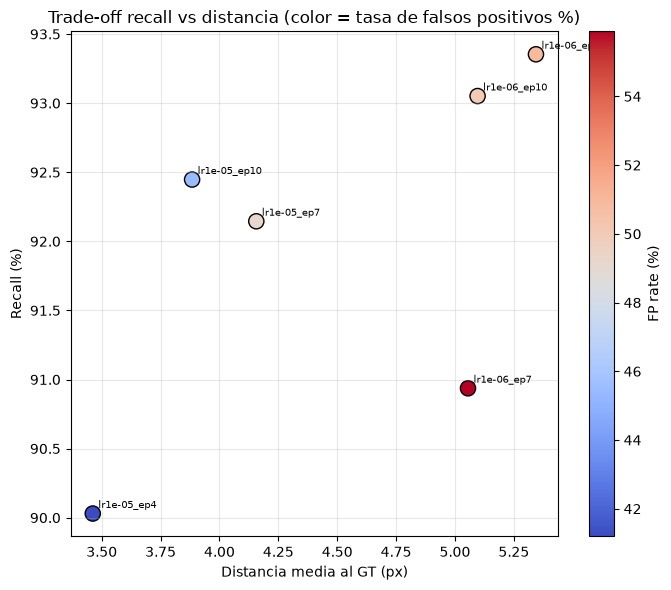


Informe comparativo guardado en /workspace/TFM/outputs/grid_models/informe_comparativo_grid_search.pdf
Informes individuales por combinación en /workspace/TFM/outputs/grid_models/informes/


,tag,phase2_lr,phase2_epochs,epochs_run,best_val_loss,mean_dist_px,recall_%,fp_rate_%
0,lr1e-05_ep4,0.000010,4,10,0.00220,3.46,90.0,41.2
1,lr1e-05_ep10,0.000010,10,9,0.00198,3.88,92.4,45.4
2,lr1e-05_ep7,0.000010,7,9,0.00185,4.16,92.1,49.1
3,lr1e-06_ep7,0.000001,7,9,0.00212,5.06,90.9,55.9
4,lr1e-06_ep10,0.000001,10,9,0.00196,5.10,93.1,50.0
5,lr1e-06_ep4,0.000001,4,7,0.00222,5.34,93.4,50.9


In [31]:
# ── Informe comparativo del grid search (pantalla + PDF) ─────────
#
# SWEEP_COLS son los ejes que varían en grid_results (ahora ["phase2_lr",
# "phase2_epochs"]); si cambias el grid a barrer otros hiperparámetros en el
# futuro, basta con cambiar esta lista — build_comparison_report no depende
# de cuántas combinaciones haya ni de sus nombres concretos.
SWEEP_COLS = ["phase2_lr", "phase2_epochs"]
COMPARISON_REPORT_PATH = MODELS_OUT / "informe_comparativo_grid_search.pdf"

_, report_df = save_comparison_report_pdf(
    COMPARISON_REPORT_PATH, grid_results, grid_histories, SWEEP_COLS,
    fixed_params=FIXED_PARAMS_FOR_REPORT, arch_summary=ARCH_SUMMARY_FOR_REPORT,
    phase1_epochs=PHASE1_EPOCHS,
)
print(f"\nInforme comparativo guardado en {COMPARISON_REPORT_PATH}")
print(f"Informes individuales por combinación en {GRID_REPORTS_DIR}/")

report_df

In [32]:
# Promueve la combinación con menor distancia media al GT como modelo final:
# copia su checkpoint a BEST_MODEL_PATH y recarga "model" con esos pesos para
# que toda la sección 7 (inferencia) y 8 (exportar CSV) usen el ganador del grid.
best_row = grid_results.iloc[0]
shutil.copyfile(best_row["checkpoint"], BEST_MODEL_PATH)
print(f"Modelo final promovido: {best_row['tag']} "
      f"(phase2_lr={best_row['phase2_lr']}, phase2_epochs={best_row['phase2_epochs']})")
print(f"Copiado a {BEST_MODEL_PATH}")

ckpt = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Modelo cargado (epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.5f})")

Modelo final promovido: lr1e-05_ep4 (phase2_lr=1e-05, phase2_epochs=4)
Copiado a /workspace/TFM/outputs/grid_models/tracknet_best.pth
Modelo cargado (epoch 7, val_loss 0.00220)


## 7. Inferencia sobre el clip de prueba

A partir de aquí `model` ya tiene cargados los pesos del **ganador del grid search** (sección 6). Se predice el heatmap frame a frame sobre un clip de **test** (`INFER_GAME`/`INFER_CLIP`, en `TEST_ROOT` — fuera del dataset de entrenamiento, nunca visto durante el entrenamiento ni la validación) usando `predict_clip` (con el filtro de continuidad temporal definido en la sección 5) y se comparan las predicciones con el ground truth del clip con `evaluate_against_gt`.

Las coordenadas se devuelven en la **resolución original** del frame.

In [33]:
infer_clip_dir = TEST_ROOT / INFER_GAME / INFER_CLIP
infer_frames = list_frames(infer_clip_dir)
infer_labels = pd.read_csv(infer_clip_dir / "Label.csv")
infer_labels.columns = [c.strip() for c in infer_labels.columns]
print(f"Inferencia sobre {INFER_GAME}/{INFER_CLIP} (test, no visto en entrenamiento) — {len(infer_frames)} frames")

pred_df = predict_clip(infer_frames, model, DEVICE)
print(f"Predicciones: {len(pred_df)} | con pelota detectada: {(pred_df['visibility']==1).sum()}")
pred_df.head()

Inferencia sobre game0/Clip1 (test, no visto en entrenamiento) — 600 frames
Predicciones: 600 | con pelota detectada: 564


,frame,file,ball_x,ball_y,visibility,peak
0,0,0000.jpg,NaN,NaN,0,0.000000
1,1,0001.jpg,NaN,NaN,0,0.000000
2,2,0002.jpg,NaN,NaN,0,0.323509
3,3,0003.jpg,NaN,NaN,0,0.311234
4,4,0004.jpg,NaN,NaN,0,0.311233


In [34]:
metrics = evaluate_against_gt(pred_df, infer_labels)
print(f"Distancia media al GT:   {metrics['mean_dist_px']:.2f} px (mediana {metrics['median_dist_px']:.2f} px)")
print(f"Recall (GT visible):     {metrics['recall']*100:.1f}%")
print(f"Falsos positivos (GT no visible pero el modelo detecta algo): {metrics['false_positive_rate']*100:.1f}%")

Distancia media al GT:   nan px (mediana nan px)
Recall (GT visible):     nan%
Falsos positivos (GT no visible pero el modelo detecta algo): 94.0%


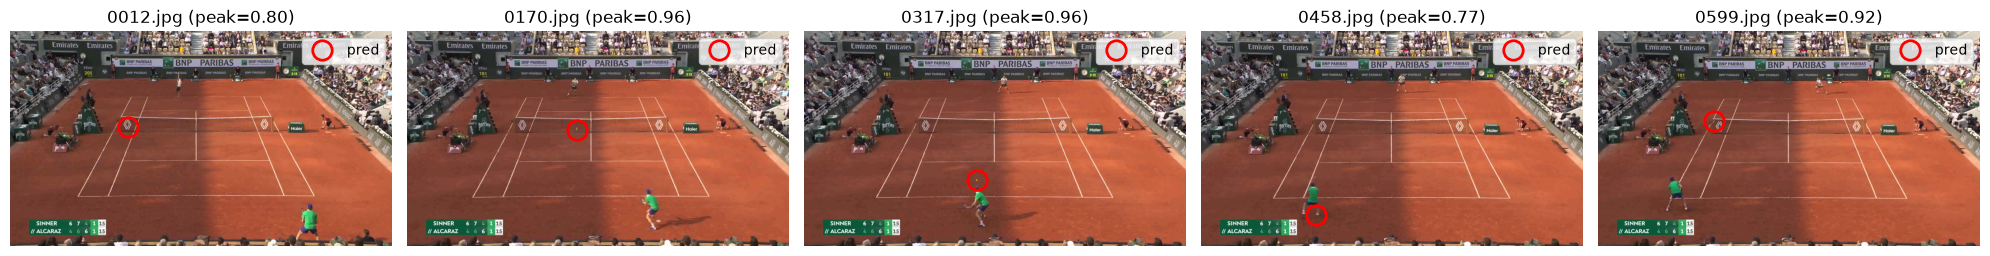

In [35]:
# 5 frames de ejemplo con predicción (rojo) vs ground truth (verde)
valid = pred_df[pred_df["visibility"] == 1]
show_idx = np.linspace(0, len(valid) - 1, num=min(5, len(valid)), dtype=int)
fig, axes = plt.subplots(1, len(show_idx), figsize=(4 * len(show_idx), 4))
if len(show_idx) == 1:
    axes = [axes]
for ax, i in zip(axes, show_idx):
    row = valid.iloc[i]
    img = cv2.cvtColor(cv2.imread(str(infer_clip_dir / row["file"])), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.plot(row["ball_x"], row["ball_y"], "o", markersize=14, markerfacecolor="none",
            markeredgecolor="red", markeredgewidth=2, label="pred")
    gt = infer_labels[infer_labels["file name"] == row["file"]].iloc[0]
    if gt["visibility"] == 1:
        ax.plot(gt["x-coordinate"], gt["y-coordinate"], "x", markersize=14,
                markeredgecolor="lime", markeredgewidth=2, label="gt")
    ax.set_title(f"{row['file']} (peak={row['peak']:.2f})")
    ax.axis("off")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 8. Exportar CSV

Se construye `ball_positions.csv` con el esquema acordado. `is_bounce` se toma del `status` del `Label.csv` original cuando está disponible para el frame; en frames donde la pelota no se detecta se rellenan `ball_x`, `ball_y` con `NaN` y `visibility=0`.

In [36]:
infer_labels["status"] = infer_labels["status"].fillna(0).astype(int)
gt_map = {row["file name"]: row["status"] for _, row in infer_labels.iterrows()}

out = pd.DataFrame({
    "clip": f"{INFER_GAME}/{INFER_CLIP}",
    "frame": pred_df["frame"],
    "ball_x": pred_df["ball_x"],
    "ball_y": pred_df["ball_y"],
    "visibility": pred_df["visibility"],
    "is_bounce": pred_df["file"].map(gt_map).fillna(0).astype(int),
})
out.to_csv(OUTPUT_CSV, index=False)
print(f"Guardado {len(out)} filas en {OUTPUT_CSV}")
out.head()

Guardado 600 filas en /workspace/TFM/outputs/tracking/ball_positions.csv


,clip,frame,ball_x,ball_y,visibility,is_bounce
0,game0/Clip1,0,NaN,NaN,0,0
1,game0/Clip1,1,NaN,NaN,0,0
2,game0/Clip1,2,NaN,NaN,0,0
3,game0/Clip1,3,NaN,NaN,0,0
4,game0/Clip1,4,NaN,NaN,0,0


In [37]:
# ── Cargar modelo ────────────────────────────────────
ckpt = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Modelo cargado (epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.5f})")


# ── Parámetros ──────────────────────────────────────
VIZ_GAME      = "game1"
VIZ_CLIP      = "Clip1"
VIZ_THRESHOLD = 0.3
FPS           = 25
# ────────────────────────────────────────────────────

viz_clip_dir  = DATASET_ROOT / VIZ_GAME / VIZ_CLIP
viz_frames    = list_frames(viz_clip_dir)
viz_labels    = pd.read_csv(viz_clip_dir / "Label.csv")
viz_labels.columns = [c.strip() for c in viz_labels.columns]
viz_labels["status"] = viz_labels["status"].fillna(0).astype(int)
gt_map_viz    = {row["file name"]: (row["x-coordinate"], row["y-coordinate"], row["visibility"])
                 for _, row in viz_labels.iterrows()}

# Inferencia
model.eval()
HEATMAP_THRESHOLD = VIZ_THRESHOLD
viz_pred = predict_clip(viz_frames, model, DEVICE)

# Construir vídeo
sample_img = cv2.imread(str(viz_frames[0]))
h, w = sample_img.shape[:2]
video_path = str(OUTPUTS_ROOT / f"{VIZ_GAME}_{VIZ_CLIP}_pred.mp4")

writer = cv2.VideoWriter(
    video_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    FPS, (w, h)
)

for _, row in viz_pred.iterrows():
    frame_path = viz_clip_dir / row["file"]
    img = cv2.imread(str(frame_path))

    # Ground truth (verde)
    fname = row["file"]
    if fname in gt_map_viz:
        gx, gy, gvis = gt_map_viz[fname]
        if gvis == 1 and not pd.isna(gx):
            cv2.drawMarker(img, (int(gx), int(gy)), (0, 255, 0),
                           cv2.MARKER_CROSS, 20, 2)

    # Predicción (rojo)
    if row["visibility"] == 1:
        cv2.circle(img, (int(row["ball_x"]), int(row["ball_y"])),
                   12, (0, 0, 255), 2)

    writer.write(img)

writer.release()
print(f"Vídeo guardado en {video_path}")

# Mostrar inline en Colab
mp4 = open(video_path, "rb").read()
b64 = b64encode(mp4).decode()
display(HTML(f"""
  <video width="854" height="480" controls>
    <source src="data:video/mp4;base64,{b64}" type="video/mp4">
  </video>
"""))

Modelo cargado (epoch 7, val_loss 0.00220)
Vídeo guardado en /workspace/TFM/outputs/game1_Clip1_pred.mp4
